# ATLAS tutorial: river discharge statistics by HydroBASINS

This notebook converts preprocessed **GLOFAS river discharge** data into monthly statistics over hydrological basins.

The original notebook was named `downscaling`, but the workflow does not perform a statistical or dynamical downscaling. It aggregates the GLOFAS grid over HydroBASINS polygons and produces basin level monthly discharge indicators. For this reason, a more appropriate name is **river discharge basin statistics** or **HydroBASINS aggregation**.

This revised version saves CSV files with a `geometry` column in WKT format, so they can be read by the station integration and maps notebook.

The notebook is organised as a step by step tutorial for users who are not Python experts. In most cases, users only need to edit the **Input parameters** section and then run the notebook from top to bottom.

## What this notebook does

1. Imports the required Python packages.
2. Defines generic input and output paths.
3. Loads the country boundary.
4. Loads HydroBASINS polygons at two spatial levels.
5. Clips the basins to the selected country.
6. Loads the preprocessed GLOFAS river discharge dataset.
7. Computes the average discharge for each month and for each basin.
8. Saves the basin statistics as GeoJSON and CSV files.

## Expected folder structure

This notebook assumes that the preprocessing notebook has already created a processed NetCDF file here:

```text
../data/glofas/processed/{COUNTRY}/
```

For example, if `COUNTRY = "ecuador"`, the notebook will read from:

```text
../data/glofas/processed/ecuador/
```

The output files will be saved here:

```text
../data/glofas/basin_statistics/{COUNTRY}/
```


## Step 1. Import required packages

Run this cell first. These packages are used to read NetCDF files, handle geospatial vector data, calculate zonal statistics and save the outputs.


In [1]:
from pathlib import Path
import warnings

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio as rio
import rasterstats as rstats
import xarray as xr

warnings.filterwarnings("ignore")


ERROR 1: PROJ: proj_create_from_database: Open of /home/alessandrom/anaconda3/envs/bias_correction_conda/share/proj failed


## Step 2. Input parameters

Edit only this section for normal use.

### Country

`COUNTRY` is used to find the input folder and to create the output folder. Keep it lowercase when it is used as a folder name.

### Input data

`INPUT_DIR` points to the processed GLOFAS NetCDF files created by the preprocessing notebook.

### Ancillary geospatial data

`COUNTRY_SHAPEFILE_PATH` must point to the Natural Earth country boundary shapefile.

### HydroBASINS data
HydroBASINS catchment boundaries can be downloaded from the HydroSHEDS portal: https://www.hydrosheds.org/products/hydrobasins . For countries in South America, download the **South America (sa)** dataset and extract the archive into the project data directory.

The workflow uses HydroBASINS levels 5 and 12 (`hybas_sa_lev05_v1c.shp` and `hybas_sa_lev12_v1c.shp`) to aggregate river discharge values from GLOFAS and compute basin-scale statistics.

`HYDROBASINS_L5_PATH` and `HYDROBASINS_L12_PATH` must point to the HydroBASINS shapefiles. The original notebook used the South America files, which are appropriate for Ecuador. For countries in other continents, replace these paths with the corresponding HydroBASINS files.

### Output data

The notebook saves one output per month. By default it saves both GeoJSON and CSV files.


In [3]:
# =========================
# COUNTRY
# =========================

# Country name used in folder paths. Keep it lowercase.
COUNTRY = "ecuador"

# Country name exactly as written in the Natural Earth shapefile.
COUNTRY_NAME_IN_SHAPEFILE = "Ecuador"


# =========================
# INPUT AND OUTPUT PATHS
# =========================

# Folder containing the processed GLOFAS NetCDF files created by the preprocessing notebook.
INPUT_DIR = Path("../data/processed/river_discharge") / COUNTRY

# Optional: set a specific processed file.
# Leave as None to automatically use the first *_processed.nc file found in INPUT_DIR.
PROCESSED_GLOFAS_FILE = INPUT_DIR / "river_discharge_1996-01_2025-12_processed.nc"

# Folder where the basin statistics will be saved.
OUTPUT_DIR = Path("../data/basin_statistics") / COUNTRY

# Country boundary shapefile.
COUNTRY_SHAPEFILE_PATH = Path("../world_map/ne_50m_admin_0_countries.shp")

# HydroBASINS shapefiles.
# Replace these paths if your country is not in South America.
HYDROBASINS_L5_PATH = Path("../hydrobasins/hybas_lake_sa_lev05_v1c.shp")
HYDROBASINS_L12_PATH = Path("../hydrobasins/hybas_lake_sa_lev12_v1c.shp")


# =========================
# PROCESSING OPTIONS
# =========================

# Name of the discharge variable inside the processed GLOFAS NetCDF file.
VARIABLE_NAME = "dis24"

# Values below this threshold are ignored before calculating basin means.
# Unit depends on the original GLOFAS variable metadata, usually m3/s for river discharge.
MIN_DISCHARGE = 1

# HydroBASINS levels used in the output.
BASIN_LEVELS = [5, 12]

# Months to process. Use range(1, 13) for all months.
MONTHS = range(1, 2)

# Output formats.
# CSV files now keep the geometry as WKT, so that the station integration notebook can read them.
SAVE_GEOJSON = True
SAVE_CSV = True

# Create the output folder if it does not exist.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Step 3. Helper functions

Run this cell without editing it.

The functions below check the input files, load geospatial layers, calculate zonal statistics and save the outputs in a consistent way.


In [4]:
def find_processed_glofas_file(input_dir, processed_file=None, variable="river_discharge"):
    """
    Find the processed GLOFAS NetCDF file created by the preprocessing notebook.

    If processed_file is provided, the function checks that it exists and uses it.
    Otherwise, it searches the input folder for files ending in *_processed.nc.
    """
    input_dir = Path(input_dir)

    if processed_file is not None:
        processed_file = Path(processed_file)
        if not processed_file.exists():
            raise FileNotFoundError(f"Processed GLOFAS file not found: {processed_file}")
        return processed_file

    candidates = sorted(input_dir.glob(f"{variable}_*_processed.nc"))

    if not candidates:
        candidates = sorted(input_dir.glob("*.nc"))

    if not candidates:
        raise FileNotFoundError(
            f"No processed NetCDF file found in {input_dir}. "
            "Run the preprocessing notebook first and check INPUT_DIR."
        )

    if len(candidates) > 1:
        print("Multiple NetCDF files found. Using the first one:")
        for file in candidates:
            print(f"  {file.name}")

    return candidates[0]


def get_country_name(country, country_name_in_shapefile=None):
    """
    Return the country name used to select the Natural Earth geometry.
    """
    if country_name_in_shapefile is not None:
        return country_name_in_shapefile
    return country.capitalize()


def load_country_geometry(shapefile_path, country_name):
    """
    Load the selected country boundary from the Natural Earth shapefile.
    """
    shapefile_path = Path(shapefile_path)
    if not shapefile_path.exists():
        raise FileNotFoundError(f"Country shapefile not found: {shapefile_path}")

    countries = gpd.read_file(shapefile_path)

    # The original notebook used the ADMIN column. Some Natural Earth versions may also contain NAME_EN.
    name_column = "ADMIN" if "ADMIN" in countries.columns else "NAME_EN"

    if country_name not in countries[name_column].values:
        available = ", ".join(sorted(countries[name_column].astype(str).unique())[:20])
        raise ValueError(
            f"Country '{country_name}' not found in column '{name_column}'. "
            f"Check COUNTRY_NAME_IN_SHAPEFILE. Examples available: {available}"
        )

    return countries.loc[countries[name_column] == country_name, [name_column, "geometry"]].iloc[0]


def load_and_clip_hydrobasins(hydrobasins_path, country_geometry):
    """
    Load a HydroBASINS shapefile, remove lake polygons and clip it to the selected country.
    """
    hydrobasins_path = Path(hydrobasins_path)
    if not hydrobasins_path.exists():
        raise FileNotFoundError(f"HydroBASINS shapefile not found: {hydrobasins_path}")

    basins = gpd.read_file(hydrobasins_path)

    if "LAKE" in basins.columns:
        basins = basins[basins["LAKE"] == 0].copy()

    country_gdf = gpd.GeoDataFrame(
        {"name": [country_geometry.name]},
        geometry=[country_geometry.geometry],
        crs=basins.crs,
    )

    if country_gdf.crs != basins.crs:
        country_gdf = country_gdf.to_crs(basins.crs)

    clipped = gpd.clip(basins, country_gdf.geometry.iloc[0])
    clipped = clipped.reset_index(drop=True)

    if clipped.empty:
        raise ValueError("No HydroBASINS polygons intersect the selected country. Check the HydroBASINS continent file.")

    return clipped


def get_affine_transform(netcdf_path, variable_name):
    """
    Get the raster affine transform needed by rasterstats.
    """
    netcdf_path = Path(netcdf_path)

    try:
        with rio.open(netcdf_path) as src:
            if src.subdatasets:
                variable_subdataset = f'NETCDF:"{netcdf_path}":{variable_name}'
                with rio.open(variable_subdataset) as variable_src:
                    return variable_src.transform
            return src.transform
    except Exception:
        variable_subdataset = f'NETCDF:"{netcdf_path}":{variable_name}'
        with rio.open(variable_subdataset) as variable_src:
            return variable_src.transform


def calculate_basin_mean(basins, data_array, affine, variable_name):
    """
    Calculate the mean value of a raster variable inside each basin polygon.
    """
    values = data_array[variable_name].values

    stats = rstats.zonal_stats(
        basins.geometry,
        values,
        affine=affine,
        stats="mean",
        nodata=np.nan,
        all_touched=True,
    )

    output = basins.copy()
    output["mean_river_discharge"] = [item["mean"] for item in stats]
    return output


def save_basin_outputs(gdf, output_dir, country, level, month, save_geojson=True, save_csv=True):
    """
    Save basin statistics for one month and one HydroBASINS level.

    Important: the CSV keeps the geometry as WKT text.
    The station integration notebook needs this geometry column to rebuild a GeoDataFrame.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    month_text = f"{month:02d}"
    base_name = f"river_discharge_l{level}_{country}_m{month}"

    if save_geojson:
        geojson_path = output_dir / f"{base_name}.geojson"
        gdf.to_file(geojson_path, driver="GeoJSON")
        print(f"Saved GeoJSON: {geojson_path}")

    if save_csv:
        csv_path = output_dir / f"{base_name}.csv"
        table = gdf.copy()
        table["geometry"] = table.geometry.to_wkt()
        table.to_csv(csv_path, index=False)
        print(f"Saved CSV: {csv_path}")


## Step 4. Check input paths

Run this cell before processing. It prints the main input and output paths and confirms which GLOFAS file will be used.


In [5]:
processed_file = find_processed_glofas_file(INPUT_DIR, PROCESSED_GLOFAS_FILE)
country_name = get_country_name(COUNTRY, COUNTRY_NAME_IN_SHAPEFILE)

print(f"Country folder: {COUNTRY}")
print(f"Country name in shapefile: {country_name}")
print(f"Input folder: {INPUT_DIR}")
print(f"Processed GLOFAS file: {processed_file}")
print(f"Output folder: {OUTPUT_DIR}")


Country folder: ecuador
Country name in shapefile: Ecuador
Input folder: ../data/processed/river_discharge/ecuador
Processed GLOFAS file: ../data/processed/river_discharge/ecuador/river_discharge_1991-01_1991-01_processed.nc
Output folder: ../data/basin_statistics/ecuador


## Step 5. Load the country boundary

This geometry is used to select only the HydroBASINS polygons that intersect the country.


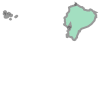

In [6]:
country_geometry = load_country_geometry(COUNTRY_SHAPEFILE_PATH, country_name)
country_geometry.geometry


## Step 6. Load and clip HydroBASINS polygons

HydroBASINS level 5 represents larger basins. HydroBASINS level 12 represents smaller and more detailed basins.

This step removes lake polygons when the `LAKE` attribute is available, then clips the basins to the selected country.


In [7]:
basins_by_level = {
    5: load_and_clip_hydrobasins(HYDROBASINS_L5_PATH, country_geometry),
    12: load_and_clip_hydrobasins(HYDROBASINS_L12_PATH, country_geometry),
}

for level, basins in basins_by_level.items():
    print(f"HydroBASINS level {level}: {len(basins)} polygons after clipping")


HydroBASINS level 5: 11 polygons after clipping
HydroBASINS level 12: 2110 polygons after clipping


## Step 7. Load the processed GLOFAS dataset

The dataset is loaded once and reused for all monthly calculations.

The variable used for the calculation is defined by `VARIABLE_NAME` in the input parameters section.


In [8]:
dataset = xr.open_dataset(processed_file)

if VARIABLE_NAME not in dataset.data_vars:
    raise KeyError(
        f"Variable '{VARIABLE_NAME}' not found in the dataset. "
        f"Available variables: {list(dataset.data_vars)}"
    )

affine = get_affine_transform(processed_file, VARIABLE_NAME)

dataset


<xarray.Dataset> Size: 5MB
Dimensions:    (time: 31, latitude: 130, longitude: 330)
Coordinates:
  * time       (time) datetime64[ns] 248B 1991-01-01 1991-01-02 ... 1991-01-31
  * latitude   (latitude) float32 520B 1.475 1.425 1.375 ... -4.925 -4.975
  * longitude  (longitude) float32 1kB -91.67 -91.62 -91.58 ... -75.27 -75.23
Data variables:
    dis24      (time, latitude, longitude) float32 5MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-12T10:02 GRIB to CDM+CF via cfgrib-0.9.1...

## Step 8. Calculate monthly basin statistics

For each month, the notebook calculates the average river discharge over the available years. Then it calculates the mean value inside each HydroBASINS polygon.

Values below `MIN_DISCHARGE` are masked before the zonal statistics are calculated. This reduces noise in areas with very low or no river discharge.


In [9]:
for month in MONTHS:
    print(f"Processing month {month:02d}")

    monthly_data = dataset.groupby("time.month").mean().sel(month=month).drop_vars("month")
    monthly_data = monthly_data.where(monthly_data[VARIABLE_NAME] >= MIN_DISCHARGE)

    for level in BASIN_LEVELS:
        basins = basins_by_level[level]
        basin_statistics = calculate_basin_mean(
            basins=basins,
            data_array=monthly_data,
            affine=affine,
            variable_name=VARIABLE_NAME,
        )

        save_basin_outputs(
            gdf=basin_statistics,
            output_dir=OUTPUT_DIR,
            country=COUNTRY,
            level=level,
            month=month,
            save_geojson=SAVE_GEOJSON,
            save_csv=SAVE_CSV,
        )

print("Processing completed.")


Processing month 01
Saved GeoJSON: ../data/basin_statistics/ecuador/river_discharge_l5_ecuador_m1.geojson
Saved CSV: ../data/basin_statistics/ecuador/river_discharge_l5_ecuador_m1.csv
Saved GeoJSON: ../data/basin_statistics/ecuador/river_discharge_l12_ecuador_m1.geojson
Saved CSV: ../data/basin_statistics/ecuador/river_discharge_l12_ecuador_m1.csv
Processing completed.


## Step 9. Check the generated files

Run this final cell to list the files created by the notebook.


In [10]:
created_files = sorted(OUTPUT_DIR.glob("river_discharge_*"))

print(f"Number of files created: {len(created_files)}")
for file in created_files[:20]:
    print(file.name)

if len(created_files) > 20:
    print("...")


Number of files created: 4
river_discharge_l12_ecuador_m1.csv
river_discharge_l12_ecuador_m1.geojson
river_discharge_l5_ecuador_m1.csv
river_discharge_l5_ecuador_m1.geojson
